In [ ]:
from __future__ import annotations

import random
from dataclasses import dataclass
from typing import ClassVar, Final, Literal, NamedTuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [ ]:
env = gym.make('CartPole-v1')
print("Environment observation space: " + str(env.observation_space.shape))  # cart position, cart velocity, pole angle, pole angular velocity
print("Possible actions: " + str(env.action_space.n))

# Goal: maximise episode steps (truncated at max. 500 steps)
# Termination criteria:
    # Termination: Pole Angle is greater than ±12°
    # Termination: Cart Position is greater than ±2.4 (center of the cart reaches the edge of the display)
    # Truncation: Episode length is greater than 500 (200 for v0)

Environment observation space: (4,)
Possible actions: 2


# Policy: Random action

In [ ]:
env = gym.make('CartPole-v1')
obs, info = env.reset(seed=42)

print(f"Starting observation: {obs}")  # [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]

episode_over = False
total_reward = 0
while not episode_over:
    action = random.randint(0, env.action_space.n-1)
    obs, reward, terminated, truncated, info = env.step(action)
    
    print(
        "\nObservation: " + str(obs),
        "Reward: " + str(reward),
        "Terminated:" + str(terminated),
        "Truncated:" + str(truncated),
        "Info:" + str(info)
    , sep="\n")
    total_reward += reward

    episode_over = terminated or truncated
    
print("\nTotal Reward: " + str(total_reward))

env.close()

Starting observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]

Observation: [ 0.02727336  0.18847767  0.03625453 -0.26141977]
Reward: 1.0
Terminated:False
Truncated:False
Info:{}

Observation: [ 0.03104291  0.38306385  0.03102613 -0.5424507 ]
Reward: 1.0
Terminated:False
Truncated:False
Info:{}

Observation: [ 0.03870419  0.1875199   0.02017712 -0.24015574]
Reward: 1.0
Terminated:False
Truncated:False
Info:{}

Observation: [ 0.04245459 -0.0078844   0.015374    0.0588227 ]
Reward: 1.0
Terminated:False
Truncated:False
Info:{}

Observation: [ 0.0422969  -0.20322338  0.01655046  0.3563163 ]
Reward: 1.0
Terminated:False
Truncated:False
Info:{}

Observation: [ 0.03823243 -0.00834059  0.02367678  0.06889778]
Reward: 1.0
Terminated:False
Truncated:False
Info:{}

Observation: [ 0.03806562  0.18643405  0.02505474 -0.21622196]
Reward: 1.0
Terminated:False
Truncated:False
Info:{}

Observation: [ 0.0417943   0.38118902  0.0207303  -0.5008974 ]
Reward: 1.0
Terminated:False
Truncated:False


# Q-learning

In [4]:
env.observation_space.__dict__

{'dtype': dtype('float32'),
 '_shape': (4,),
 'low': array([-4.8       ,        -inf, -0.41887903,        -inf], dtype=float32),
 'bounded_below': array([ True, False,  True, False]),
 'high': array([4.8       ,        inf, 0.41887903,        inf], dtype=float32),
 'bounded_above': array([ True, False,  True, False]),
 'low_repr': None,
 'high_repr': None,
 '_np_random': None}

In [ ]:
ALPHA: Final[float] = 0.05  # how much to update the Q table by overall
EPSILON: Final[float] = 1.0  # exploration
EPSILON_MIN: Final[float] = 0.01
EPSILON_DECAY: Final[float] = 0.99
GAMMA: Final[float] = 0.99  # how much the Q table is affected by the future move

class BinnedStates(NamedTuple):
    CartPosition: int
    CartVelocity: int
    PoleAngle: int
    PoleVelocity: int
    
    @classmethod
    def from_obs(cls, obs: np.typing.NDArray[np.float32], bins: list[np.typing.NDArray[np.float32]]) -> BinnedStates:
        indices = tuple(
            int(
                np.clip(
                    np.digitize(obs_1d, bin_edges) - 1,
                    0,
                    len(bin_edges-1)
                )
            )
            for obs_1d, bin_edges in zip(obs, bins)
        )
        return cls(*indices)
@dataclass
class Env:
    bins: ClassVar[list[np.typing.NDArray]] = [
        np.linspace(-4.8, 4.8, 2, dtype=np.float32),  # cart position
        np.linspace(-5.0, 5.0, 10, dtype=np.float32),  # cart velocity
        np.linspace(-0.418, 0.418, 10, dtype=np.float32),  # pole angle
        np.linspace(-5.0, 5.0, 10, dtype=np.float32),  # pole velocity
    ]
    Action: Literal[0, 1]
    actions: ClassVar[list[Action]] = [0, 1]
    Qtable: ClassVar[np.typing.NDArray] = np.zeros((len(bins[0]), len(bins[1]), len(bins[2]), len(bins[3]), 2), dtype=np.float32)
    
    def update_q_value_non_terminal(prev_state: BinnedStates, new_state: BinnedStates, action: Action, reward: Literal[1.0, 0.0]):
        prev_q_values = Env.Qtable[prev_state.CartPosition][prev_state.CartVelocity][prev_state.PoleAngle][prev_state.PoleVelocity]
        new_q_values = Env.Qtable[new_state.CartPosition][new_state.CartVelocity][new_state.PoleAngle][new_state.PoleVelocity]
        prev_q_values[action] = prev_q_values[action] + ALPHA * (reward + GAMMA * max(new_q_values) - prev_q_values[action])

    def update_q_value_terminal(prev_state: BinnedStates, action: Action, reward: Literal[1.0, 0.0]):
        prev_q_values = Env.Qtable[prev_state.CartPosition][prev_state.CartVelocity][prev_state.PoleAngle][prev_state.PoleVelocity]
        prev_q_values[action] = prev_q_values[action] + ALPHA * (reward - prev_q_values[action])

In [ ]:
TOTAL_RUNS = 10_000
env = gym.make('CartPole-v1')

episode_rewards = []

for _ in tqdm(range(TOTAL_RUNS)):
    obs, info = env.reset()

    episode_over = False
    total_reward = 0
    
    while not episode_over:
        prev_state = BinnedStates.from_obs(obs=obs, bins=Env.bins)
        q_values = Env.Qtable[prev_state.CartPosition][prev_state.CartVelocity][prev_state.PoleAngle][prev_state.PoleVelocity]
        if random.random() < EPSILON:
            action = random.choice(Env.actions)
        else:
            action = np.argmax(q_values)
        
        obs, reward, terminated, truncated, info = env.step(action)
        
        new_state = BinnedStates.from_obs(obs=obs, bins=Env.bins)
        
        episode_over = terminated or truncated
        
        if not episode_over:
            Env.update_q_value_non_terminal(
                prev_state=prev_state,
                new_state=new_state,
                action=action,
                reward=reward
            )
        else:
            Env.update_q_value_terminal(
                prev_state=prev_state,
                action=action,
                reward=reward
            )
        
        total_reward += reward

    EPSILON = max(
        EPSILON_MIN,
        EPSILON_DECAY * EPSILON
    )

    TOTAL_RUNS -= 1
    episode_rewards.append(total_reward)

env.close()

100%|██████████| 10000/10000 [00:20<00:00, 492.46it/s]


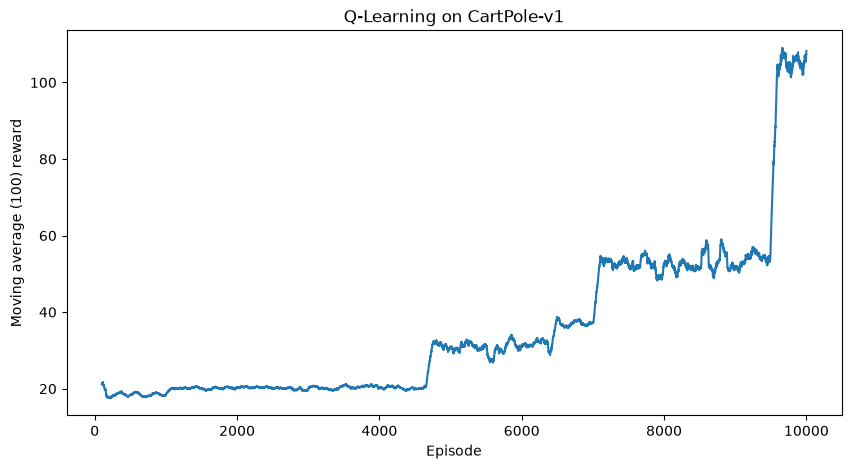

In [7]:
plt.figure(figsize=(10, 5))

window = 100

moving_avg = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid",
)

plt.plot(
    np.arange(window, len(episode_rewards) + 1),
    moving_avg,
)

plt.xlabel("Episode")
plt.ylabel(f"Moving average ({window}) reward")
plt.title("Q-Learning on CartPole-v1")

plt.show()